# EDA (Exploratory Data Analysis)

In [1]:
# import libraries

import os
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# current working directories

print(os.getcwd())

c:\Users\Greesha Vaishnavi\Desktop\dsprojects\E_Commerce_Customer_Segmentation\research


In [3]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

local_data_file = PROJECT_ROOT / "artifacts" / "data_ingestion" / "Online Retail.xlsx"

print("Project Root:", PROJECT_ROOT)
print("File exists:", local_data_file.exists())

Project Root: c:\Users\Greesha Vaishnavi\Desktop\dsprojects\E_Commerce_Customer_Segmentation
File exists: True


In [4]:
# Load the ingested data path

df = pd.read_excel(local_data_file)   # read the excel data in dataframe

df.head()  

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# tails of the data frame from last 5

df.tail() 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [6]:
# any 5 random rows 

df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
521076,580311,84820,DANISH ROSE TRINKET TRAYS,2,2011-12-02 14:48:00,5.95,18245.0,United Kingdom
251570,559055,22494,EMERGENCY FIRST AID TIN,1,2011-07-05 17:09:00,2.46,NaN,United Kingdom
129555,547386,22217,T-LIGHT HOLDER HANGING LACE,4,2011-03-22 15:52:00,2.46,NaN,United Kingdom
338199,566518,23196,VINTAGE LEAF MAGNETIC NOTEPAD,2,2011-09-13 11:24:00,1.45,17779.0,United Kingdom
128757,547359,22897,OVEN MITT APPLES DESIGN,1,2011-03-22 12:27:00,1.45,15719.0,United Kingdom


In [7]:
# checking data shape 

df.shape

(541909, 8)

In [8]:
# column names

df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
# data information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
# finding missing values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
# finding missing value percentage

missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percentage

CustomerID     24.926694
Description     0.268311
StockCode       0.000000
InvoiceNo       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64

In [12]:
# finding duplicate rows

df.duplicated().sum()

np.int64(5268)

In [13]:
# find missing value percentage

duplicate_percentage = (df.duplicated().sum() / len(df) * 100)

duplicate_percentage

np.float64(0.9721189350979592)

In [14]:
# descriptive statistics

df.describe()        

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


mean>median right sweked and our data is strongly skewed.
min is negative , negative quantities can represent returns/cancellations

In [15]:
# include categorical information

df.describe(include="object")

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [16]:
# unique values 

df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [17]:
# Negative quantities

negative_quantity_count = (df["Quantity"] < 0).sum()

negative_quantity_count

np.int64(10624)

In [18]:
# percentage of negative quantities 

negative_quantity_percentage = (negative_quantity_count / len(df) * 100)

negative_quantity_percentage

np.float64(1.9604767590130447)

In [19]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [20]:
# find zero quantities

zero_quantity_count = (df["Quantity"] == 0).sum()

zero_quantity_count

np.int64(0)

In [21]:
# non positive unitprice

non_positive_price_count = (df["UnitPrice"] <= 0).sum()

non_positive_price_count

np.int64(2517)

In [22]:
df[df["UnitPrice"] <= 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [23]:
# cancelled invoice

cancelled_invoice_count = (
    df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

cancelled_invoice_count

np.int64(9288)

In [24]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [25]:
# Checking whether negative quantity corresponds to cancellation

negative_quantity_df = df[df["Quantity"] < 0]

negative_quantity_df["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [26]:
# Checking positive transactions

positive_sales_df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
]

positive_sales_df.shape

(530104, 8)

In [27]:
# Calculate transaction revenue temporarily

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [28]:
df["Revenue"].describe()

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

In [29]:
# checking negative revenue

(df["Revenue"] < 0).sum()

np.int64(9290)

In [30]:
df[df["Revenue"] < 0]["Revenue"].describe()

count      9290.000000
mean        -98.916750
std        2046.021054
min     -168469.600000
25%         -17.700000
50%          -8.500000
75%          -3.700000
max          -0.120000
Name: Revenue, dtype: float64

# Univariate Analysis

calculating one variable 

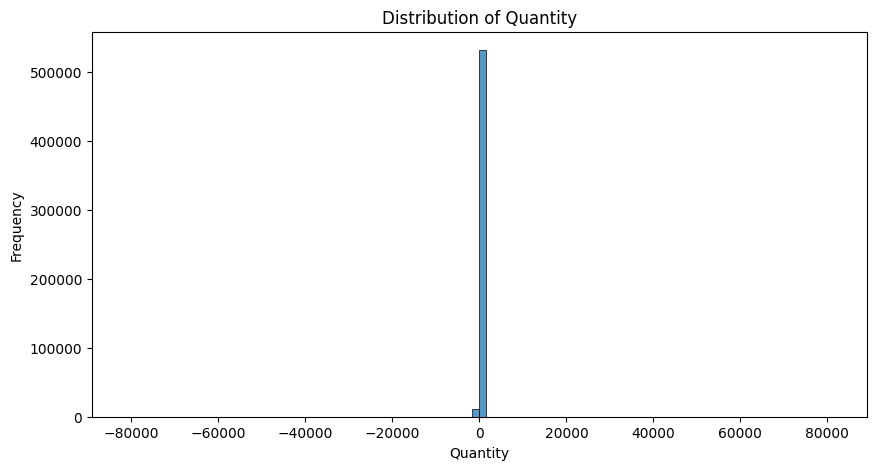

In [ ]:
# Quantity distribution(numerical data)

#checking is it normally distributed,skewed= left or right ,extreme values ,non-positive prices 

plt.figure(figsize=(10, 5))

sns.histplot(df["Quantity"], bins=100)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

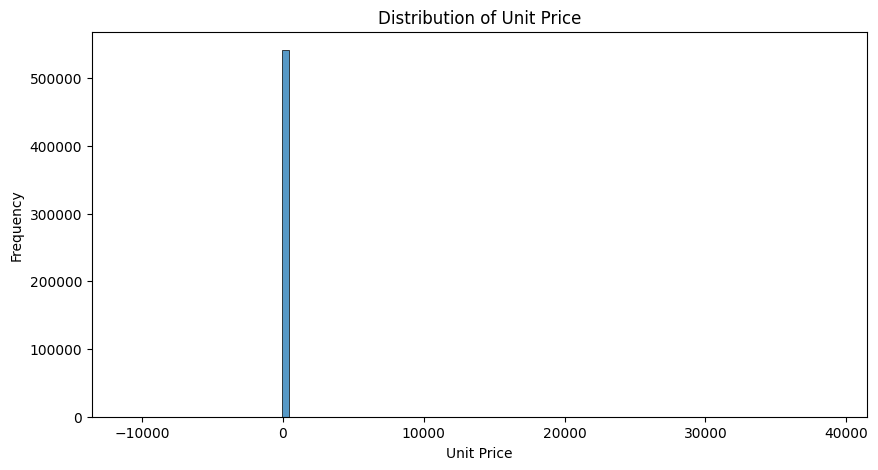

In [ ]:
# UnitPrice distribution (numerical data )

# checking typical price range,skewness,extreme values ,non-positive prices 

plt.figure(figsize=(10, 5))

sns.histplot(df["UnitPrice"], bins=100)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

In [33]:
# Country distribution (categorical data)

# we use value count 

country_counts = df["Country"].value_counts().head(15)

country_counts


Country
United Kingdom     495478
Germany              9495
France               8557
EIRE                 8196
Spain                2533
Netherlands          2371
Belgium              2069
Switzerland          2002
Portugal             1519
Australia            1259
Norway               1086
Italy                 803
Channel Islands       758
Finland               695
Cyprus                622
Name: count, dtype: int64

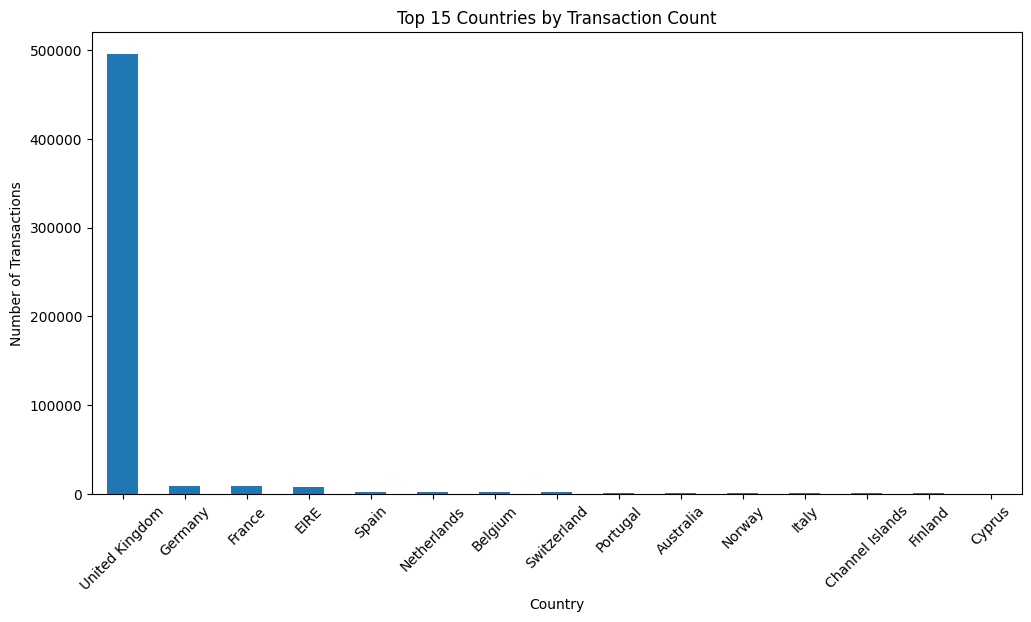

In [34]:
# plot graph 

plt.figure(figsize=(12, 6))

country_counts.plot(kind="bar")

plt.title("Top 15 Countries by Transaction Count")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

United Kingdom dominates the dataset. it has many transactions

# Date Analysis  

InvoiceDate is particularly important because we need Recency

In [35]:
df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [36]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [37]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

In [38]:
df["Year"].value_counts().sort_index()

Year
2010     42481
2011    499428
Name: count, dtype: int64

In [39]:
df["Month"].value_counts().sort_index()

Month
1     35147
2     27707
3     36748
4     29916
5     37030
6     36874
7     39518
8     35284
9     50226
10    60742
11    84711
12    68006
Name: count, dtype: int64

In [40]:
# monthly transaction pattern 

monthly_transactions = (df.groupby(["Year", "Month"]).size())

monthly_transactions

Year  Month
2010  12       42481
2011  1        35147
      2        27707
      3        36748
      4        29916
      5        37030
      6        36874
      7        39518
      8        35284
      9        50226
      10       60742
      11       84711
      12       25525
dtype: int64

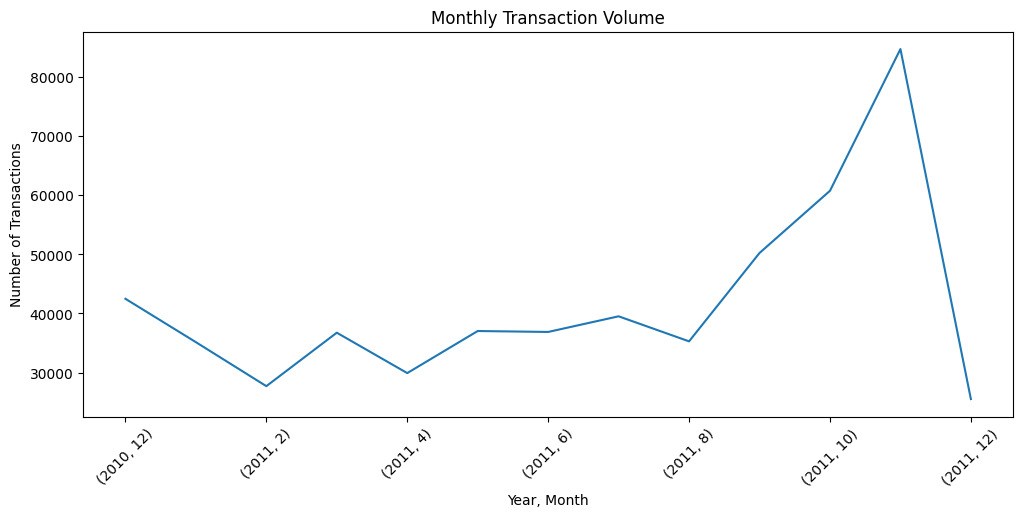

In [41]:
# plot graph

plt.figure(figsize=(12, 5))

monthly_transactions.plot()

plt.title("Monthly Transaction Volume")
plt.xlabel("Year, Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

# Customer Analysis

specific eda for the customer segementation
Customer 1 → segment
Customer 2 → segment
Customer 3 → segment


In [42]:
# Number of transactions per customer

customer_transaction_count = (df.groupby("CustomerID").size())

customer_transaction_count.describe()



count    4372.000000
mean       93.053294
std       232.471608
min         1.000000
25%        17.000000
50%        42.000000
75%       102.000000
max      7983.000000
dtype: float64

In [43]:
customer_transaction_count.sort_values(ascending=False).head(10)

CustomerID
17841.0    7983
14911.0    5903
14096.0    5128
12748.0    4642
14606.0    2782
15311.0    2491
14646.0    2085
13089.0    1857
13263.0    1677
14298.0    1640
dtype: int64

# Customer Spending Analysis

In [44]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [46]:
customer_revenue = (df.groupby("CustomerID")["Revenue"].sum())

customer_revenue

CustomerID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     176.60
18283.0    2094.88
18287.0    1837.28
Name: Revenue, Length: 4372, dtype: float64

In [47]:
customer_revenue.describe()

count      4372.000000
mean       1898.459701
std        8219.345141
min       -4287.630000
25%         293.362500
50%         648.075000
75%        1611.725000
max      279489.020000
Name: Revenue, dtype: float64

In [48]:
customer_revenue.sort_values(ascending=False).head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64

# RFM-oriented EDA

We are not creating the final RFM dataset yet.
We're simply asking whether the raw transaction data contains the information needed for RFM.
Recency = Invoice
Frequency = InvoiceNo and CustomerID
Monetary = Quantity and UnitPrice